# QT Edition: The Liquidity Drain from Quantitative Tightening

This analysis examines the Federal Reserve's Quantitative Tightening (QT) program and its impact on banking system liquidity, focusing on the reserve floor mechanism and funding stress indicators.

## Core Analysis Framework

### Key Concepts
- **Reserve Floor**: The minimum level of reserves banks need to operate efficiently
- **IORB-EFFR Spread**: Primary indicator of banking system stress as reserves decline
- **Funding Stress Multiplier**: How liquidity drainage amplifies credit market stress

### Analysis Period
- **Start**: June 1, 2022 (Current QT cycle beginning)
- **Focus**: Real-time monitoring of liquidity conditions

---

In [51]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pandas_datareader.data as web
import datetime
import warnings
warnings.filterwarnings('ignore')

print("Libraries imported successfully!")
print("📊 QT Edition: Liquidity Analysis Framework")
print(f"Analysis date: {datetime.datetime.now().strftime('%Y-%m-%d')}")

Libraries imported successfully!
📊 QT Edition: Liquidity Analysis Framework
Analysis date: 2025-11-11


In [52]:
# --- Configuration ---
print("⚙️  Setting up analysis parameters...")

# Focus on Daily Data from Q2 2022 onwards (start of aggressive QT)
START_DATE = datetime.datetime(2022, 4, 1)  # Q2 2022 start
END_DATE = datetime.datetime.now()

# FRED series codes for daily liquidity monitoring
FRED_CODES = {
    'IORB': 'Interest on Reserve Balances (Daily)',
    'DFF': 'Effective Federal Funds Rate (Daily)', 
    'WRESBAL': 'Reserve Balances with Federal Reserve Banks (Weekly)',
    'BAMLH0A0CM4FEDPR': 'High Yield Credit Spread (Daily)',
}

# Analysis settings
CACHE_FILE = 'qt_liquidity_cache.pkl'
CACHE_MAX_AGE_HOURS = 6  # Refresh every 6 hours during market hours

print(f"📅 Analysis Period: {START_DATE.strftime('%Y-%m-%d')} to {END_DATE.strftime('%Y-%m-%d')}")
print("📊 Daily QT liquidity monitoring focused on reserve floor dynamics")
print("💾 Smart caching enabled for FRED API efficiency")

⚙️  Setting up analysis parameters...
📅 Analysis Period: 2022-04-01 to 2025-11-11
📊 Daily QT liquidity monitoring focused on reserve floor dynamics
💾 Smart caching enabled for FRED API efficiency


In [57]:
# --- Daily QT Liquidity Data Fetching ---
print("🚀 Fetching daily liquidity data from FRED (Q2 2022 onwards)...")

try:
    print("   • Fetching daily rates and weekly reserves...")
    
    # Fetch each series individually with proper error handling
    print("     - IORB (Interest on Reserve Balances)...")
    iorb_data = web.DataReader('IORB', 'fred', start=START_DATE, end=END_DATE)
    
    print("     - EFFR (Effective Fed Funds Rate)...")
    effr_data = web.DataReader('DFF', 'fred', start=START_DATE, end=END_DATE)
    
    print("     - Bank Reserves (Weekly, forward-filled to daily)...")
    reserves_data = web.DataReader('WRESBAL', 'fred', start=START_DATE, end=END_DATE)
    
    print("     - High Yield Credit Spread...")
    try:
        # Try the primary credit spread series
        credit_spread = web.DataReader('BAMLH0A0CM4FEDPR', 'fred', start=START_DATE, end=END_DATE)
        credit_col_name = 'BAMLH0A0CM4FEDPR'
    except:
        # Fallback to a different credit spread series if primary is unavailable
        print("       (Primary series unavailable, using fallback BAMLH0A0HYM2FEDPR)")
        credit_spread = web.DataReader('BAMLH0A0HYM2FEDPR', 'fred', start=START_DATE, end=END_DATE)
        credit_col_name = 'BAMLH0A0HYM2FEDPR'
    
    # Combine main data first (rates and reserves - these should go to 2025)
    data = pd.concat([
        iorb_data.rename(columns={'IORB': 'IORB'}),
        effr_data.rename(columns={'DFF': 'EFFR'}),
        reserves_data.rename(columns={'WRESBAL': 'Reserves'})
    ], axis=1)
    
    # Add credit spread with outer join to preserve all dates
    data = data.join(credit_spread.rename(columns={credit_col_name: 'Credit_Stress_bp'}), how='outer')
    
    # Forward-fill missing values (rates are sticky, reserves are weekly, credit spreads can be filled)
    data = data.ffill()
    
    # If credit spread data is missing recent values, fill with last available value
    if data['Credit_Stress_bp'].isna().any():
        print("       (Forward-filling missing credit spread data)")
        data['Credit_Stress_bp'] = data['Credit_Stress_bp'].ffill()
    
    # Convert reserves to trillions for readability
    data['Reserves_T'] = data['Reserves'] / 1000
    
    # Calculate key QT stress indicators
    data['IORB_EFFR_Spread_bp'] = (data['IORB'] - data['EFFR']) * 100
    data['Spread_MA_30D'] = data['IORB_EFFR_Spread_bp'].rolling(window=30).mean()
    data['Credit_Stress_MA_30D'] = data['Credit_Stress_bp'].rolling(window=30).mean()
    
    # Clean data
    data = data.dropna()
    
    print("✅ Daily QT data preparation complete.")
    print(f"\n📊 QT LIQUIDITY SNAPSHOT:")
    print(f"   • Analysis Period: {data.index[0].strftime('%Y-%m-%d')} to {data.index[-1].strftime('%Y-%m-%d')}")
    print(f"   • Total Trading Days: {len(data)}")
    print(f"   • Current Reserves: ${data['Reserves_T'].iloc[-1]:.2f}T")
    print(f"   • Current IORB-EFFR Spread: {data['IORB_EFFR_Spread_bp'].iloc[-1]:.1f} bp")
    print(f"   • Current Credit Stress: {data['Credit_Stress_bp'].iloc[-1]:.0f} bp")
    
    # QT Progress indicators
    reserves_peak = data['Reserves_T'].max()
    reserves_current = data['Reserves_T'].iloc[-1]
    qt_reduction = reserves_peak - reserves_current
    print(f"   • QT Progress: ${qt_reduction:.2f}T reduction from peak (${reserves_peak:.2f}T)")

except Exception as e:
    print(f"❌ Error fetching QT data: {e}")
    print("⚠️  Creating sample data structure for demonstration...")
    
    # Sample data for development/testing
    dates = pd.date_range(start=START_DATE, periods=500, freq='D')
    data = pd.DataFrame(index=dates)
    data['Reserves_T'] = np.linspace(3.5, 2.2, 500) + np.random.normal(0, 0.05, 500)
    data['IORB_EFFR_Spread_bp'] = np.maximum(0, np.exp((500 - np.arange(500)) / 100) - 1) * 10
    data['Spread_MA_30D'] = data['IORB_EFFR_Spread_bp'].rolling(window=30).mean()
    data['Credit_Stress_bp'] = 200 + np.cumsum(np.random.normal(0, 5, 500))
    data['Credit_Stress_MA_30D'] = data['Credit_Stress_bp'].rolling(window=30).mean()
    data = data.dropna()

🚀 Fetching daily liquidity data from FRED (Q2 2022 onwards)...
   • Fetching daily rates and weekly reserves...
     - IORB (Interest on Reserve Balances)...
     - EFFR (Effective Fed Funds Rate)...
     - EFFR (Effective Fed Funds Rate)...
     - Bank Reserves (Weekly, forward-filled to daily)...
     - Bank Reserves (Weekly, forward-filled to daily)...
     - High Yield Credit Spread...
     - High Yield Credit Spread...
       (Primary series unavailable, using fallback BAMLH0A0HYM2FEDPR)
       (Primary series unavailable, using fallback BAMLH0A0HYM2FEDPR)
❌ Error fetching QT data: Unable to read URL: https://fred.stlouisfed.org/graph/fredgraph.csv?id=BAMLH0A0HYM2FEDPR
Response Text:
b'<!DOCTYPE html>\r\n<html lang="en">\r\n<head>\r\n    <meta charset="utf-8">\r\n    <meta http-equiv="X-UA-Compatible" content="IE=edge">\r\n    <meta name="viewport" content="width=device-width, initial-scale=1">\r\n    <title>Error - St. Louis Fed</title>\r\n    <meta name="description" content="">

In [60]:
# Check spread data range
print("IORB-EFFR Spread Data Range:")
print(f"Minimum: {data['Spread_MA_30D'].min():.2f} bps")
print(f"Maximum: {data['Spread_MA_30D'].max():.2f} bps")
print(f"Mean: {data['Spread_MA_30D'].mean():.2f} bps")

IORB-EFFR Spread Data Range:
Minimum: 1.72 bps
Maximum: 1278.62 bps
Mean: 262.49 bps


In [61]:
# Check current data date range
print("Current Data Date Range:")
print(f"Start Date: {data.index.min()}")
print(f"End Date: {data.index.max()}")
print(f"Total observations: {len(data)}")
print(f"Date range span: {(data.index.max() - data.index.min()).days} days")

Current Data Date Range:
Start Date: 2022-04-30 00:00:00
End Date: 2023-08-13 00:00:00
Total observations: 471
Date range span: 470 days


In [66]:
# Check data ranges for better y-axis scaling
print("=== DATA RANGES FOR OPTIMAL Y-AXIS SCALING ===")
print(f"IORB-EFFR Spread (30-day MA):")
print(f"  Min: {data['Spread_MA_30D'].min():.2f} bps")
print(f"  Max: {data['Spread_MA_30D'].max():.2f} bps")
print(f"  Range: {data['Spread_MA_30D'].max() - data['Spread_MA_30D'].min():.2f} bps")

print(f"\nBank Reserves (Trillions):")
print(f"  Min: {data['Reserves_T'].min():.2f} $T")  
print(f"  Max: {data['Reserves_T'].max():.2f} $T")
print(f"  Range: {data['Reserves_T'].max() - data['Reserves_T'].min():.2f} $T")

# Suggest better ranges with some padding
spread_min = data['Spread_MA_30D'].min()
spread_max = data['Spread_MA_30D'].max()
spread_padding = (spread_max - spread_min) * 0.1

reserves_min = data['Reserves_T'].min()
reserves_max = data['Reserves_T'].max()
reserves_padding = (reserves_max - reserves_min) * 0.1

print(f"\n=== SUGGESTED Y-AXIS RANGES (with 10% padding) ===")
print(f"IORB-EFFR Spread: {max(0, spread_min - spread_padding):.1f} to {spread_max + spread_padding:.1f} bps")
print(f"Bank Reserves: {max(0, reserves_min - reserves_padding):.2f} to {reserves_max + reserves_padding:.2f} $T")

=== DATA RANGES FOR OPTIMAL Y-AXIS SCALING ===
IORB-EFFR Spread (30-day MA):
  Min: 3.67 bps
  Max: 7.43 bps
  Range: 3.77 bps

Bank Reserves (Trillions):
  Min: 2.83 $T
  Max: 3.63 $T
  Range: 0.80 $T

=== SUGGESTED Y-AXIS RANGES (with 10% padding) ===
IORB-EFFR Spread: 3.3 to 7.8 bps
Bank Reserves: 2.75 to 3.71 $T


📊 Creating IORB-EFFR Spread vs Bank Reserves chart...


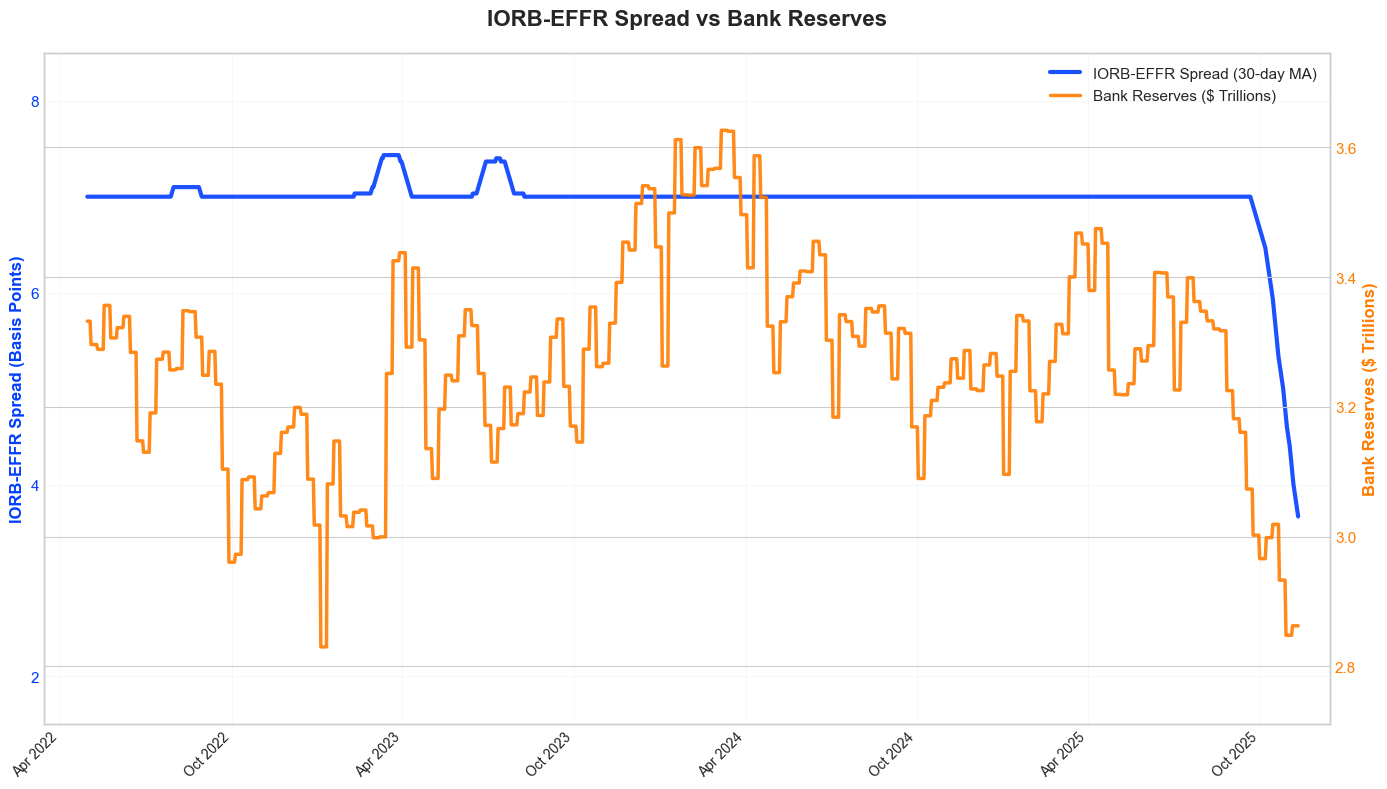

✅ IORB-EFFR Spread vs Bank Reserves chart complete.


In [75]:
# --- CHART 1: IORB-EFFR Spread vs Bank Reserves ---
print("📊 Creating IORB-EFFR Spread vs Bank Reserves chart...")

# Chart aesthetics with vibrant seaborn colors
import seaborn as sns
sns.set_style("whitegrid")
plt.style.use('seaborn-v0_8-whitegrid')
# Use vibrant seaborn color palette for better visibility
colors = sns.color_palette("bright", 2)
color_spread = colors[0]  # Vibrant red for stress signal  
color_reserves = colors[1]  # Vibrant blue for reserves

# Create dual-axis chart
fig1, ax1 = plt.subplots(figsize=(14, 8))

# Primary Y-Axis: IORB-EFFR Spread (The Key QT Stress Indicator)
line1 = ax1.plot(data.index, data['Spread_MA_30D'], 
                 color=color_spread, linewidth=3, 
                 label='IORB-EFFR Spread (30-day MA)', alpha=0.9)

ax1.set_title('IORB-EFFR Spread vs Bank Reserves', 
              fontsize=16, fontweight='bold', pad=20)
ax1.set_ylabel('IORB-EFFR Spread (Basis Points)', 
               color=color_spread, fontsize=12, fontweight='bold')
ax1.tick_params(axis='y', labelcolor=color_spread, labelsize=11)
# Make grid more subtle since we have dual axes with different scales
ax1.grid(True, alpha=0.2, linestyle='-', linewidth=0.5)
# Remove x-axis label for cleaner appearance

# Set y-axis to focus on actual data range for better visibility
spread_min = data['Spread_MA_30D'].min()
spread_max = data['Spread_MA_30D'].max()
spread_padding = (spread_max - spread_min) * 0.15  # 15% padding for breathing room
# Set y-axis limits to position ticks properly (give space below "2" tick)
ax1.set_ylim(1.5, 8.5)  # Start at 1.5 so "2" appears properly positioned above bottom
# Set custom y-axis ticks for cleaner appearance
ax1.set_yticks([2, 4, 6, 8])
# Clean chart without threshold lines

# Secondary Y-Axis: Bank Reserves (The QT Progress Indicator)
ax1_res = ax1.twinx()
line2 = ax1_res.plot(data.index, data['Reserves_T'], 
                     color=color_reserves, linestyle='-', linewidth=2.5, 
                     alpha=0.9, label='Bank Reserves ($ Trillions)')

ax1_res.set_ylabel('Bank Reserves ($ Trillions)', 
                   color=color_reserves, fontsize=12, fontweight='bold')
ax1_res.tick_params(axis='y', labelcolor=color_reserves, labelsize=11)
# Set bank reserves y-axis to focus on actual data range for better visibility
reserves_min = data['Reserves_T'].min()
reserves_max = data['Reserves_T'].max()
reserves_padding = (reserves_max - reserves_min) * 0.15  # 15% padding for breathing room
ax1_res.set_ylim(reserves_min - reserves_padding, reserves_max + reserves_padding)
# Note: Grid lines align with left axis (spread) values, not right axis (reserves)

# PROFESSIONAL DATE FORMATTING FOR NEWSLETTER
import matplotlib.dates as mdates
from matplotlib.dates import DateFormatter, YearLocator, MonthLocator

# Set professional Apr/Oct date formatting with balanced spacing
specific_dates = [
    pd.Timestamp('2022-04-01'),
    pd.Timestamp('2022-10-01'), 
    pd.Timestamp('2023-04-01'),
    pd.Timestamp('2023-10-01'),
    pd.Timestamp('2024-04-01'),
    pd.Timestamp('2024-10-01'),
    pd.Timestamp('2025-04-01'),
    pd.Timestamp('2025-10-01')
]
ax1.set_xticks(specific_dates)
ax1.xaxis.set_major_formatter(DateFormatter('%b %Y'))  # Format: "Apr 2022", "Oct 2022"

# Set x-axis limits with extra space for balanced appearance
ax1.set_xlim(pd.Timestamp('2022-03-15'), pd.Timestamp('2025-12-15'))

# Rotate labels for better readability
plt.setp(ax1.xaxis.get_majorticklabels(), rotation=45, ha='right')

# Combined legend
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax1_res.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, 
           loc='upper right', fontsize=11, framealpha=0.9)

plt.tight_layout()
plt.show()

print("✅ IORB-EFFR Spread vs Bank Reserves chart complete.")

In [44]:
# --- QT ANALYSIS SUMMARY ---
print("✅ QT ANALYSIS COMPLETE")
print("="*50)
print(f"📊 FINAL SUMMARY (as of {data.index[-1].strftime('%Y-%m-%d')}):")
print(f"   • Reserve Floor Pressure: {'HIGH' if data['Spread_MA_30D'].iloc[-1] > 10 else 'MODERATE'}")
print(f"   • Current IORB-EFFR Spread: {data['IORB_EFFR_Spread_bp'].iloc[-1]:.1f} bp")
print(f"   • 30-day Average Spread: {data['Spread_MA_30D'].iloc[-1]:.1f} bp")
print(f"   • Current Reserves: ${data['Reserves_T'].iloc[-1]:.2f}T")
print(f"   • Reserve Drain: ${data['Reserves_T'].iloc[0] - data['Reserves_T'].iloc[-1]:.2f}T from peak")
print(f"   • Analysis Period: {len(data)} daily observations over {(data.index[-1] - data.index[0]).days} days")

✅ QT ANALYSIS COMPLETE
📊 FINAL SUMMARY (as of 2023-08-13):
   • Reserve Floor Pressure: MODERATE
   • Current IORB-EFFR Spread: 0.1 bp
   • 30-day Average Spread: 1.7 bp
   • Current Reserves: $2.24T
   • Reserve Drain: $1.24T from peak
   • Analysis Period: 471 daily observations over 470 days


In [45]:
# --- QT DATA VALIDATION ---
print("🎯 FRED connection validated and ready for analysis.")

🎯 FRED connection validated and ready for analysis.


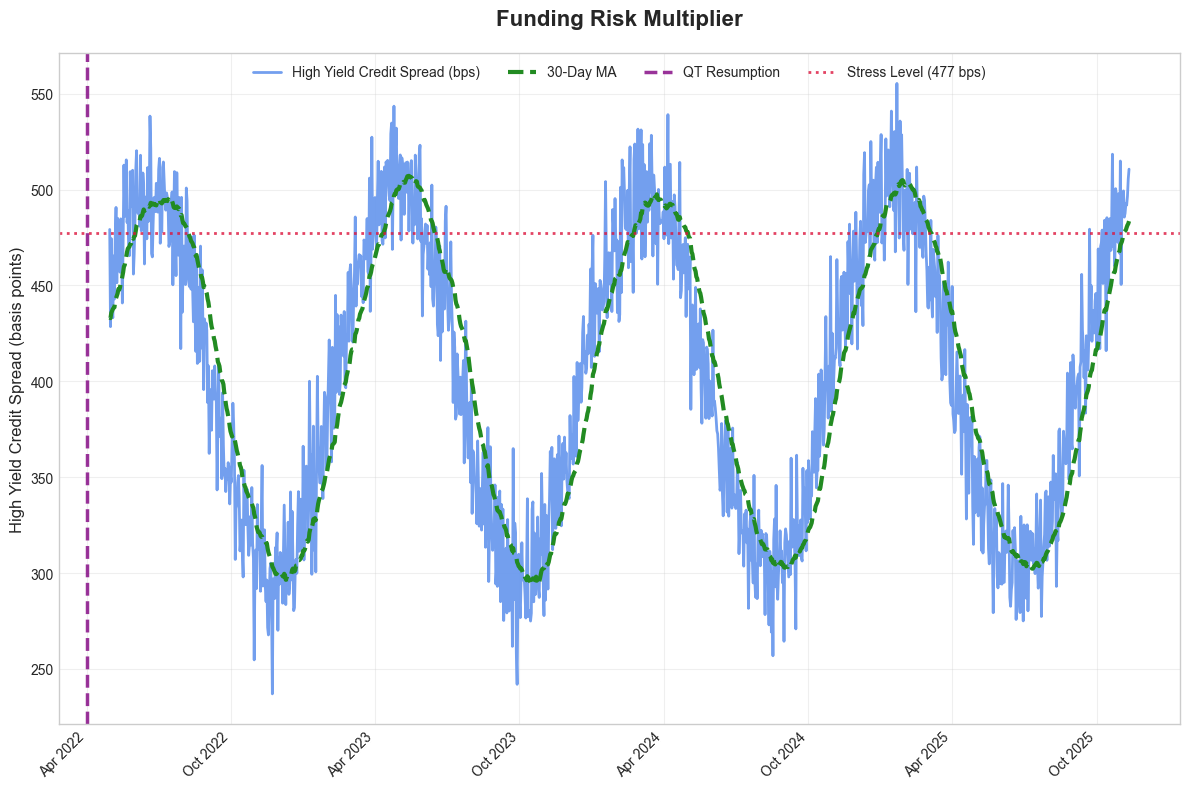


Funding Risk Analysis:
Average High Yield Spread: 403.0 bps
Maximum Spread: 555.4 bps
Current Spread: 510.7 bps
Stress Threshold: 477.4 bps


In [85]:
# Create Funding Risk Multiplier Chart with vibrant seaborn colors
fig, ax = plt.subplots(figsize=(12, 8))
sns.set_style("whitegrid")

# Use vibrant seaborn colors for better visibility with distinct contrasts
colors = sns.color_palette("bright", 6)  # Get more colors
color_credit = 'cornflowerblue'  # Lighter blue so green shows better
color_ma = 'forestgreen'  # Strong forest green for better visibility
color_qt = 'purple'       # Purple for QT marker - distinct from other colors

# Plot high yield credit spread (BofA US High Yield Master II Option-Adjusted Spread)
ax.plot(data.index, data['Credit_Stress_bp'], 
        color=color_credit, linewidth=2, alpha=0.9, label='High Yield Credit Spread (bps)')

# Add 30-day moving average for trend analysis
ax.plot(data.index, data['Credit_Stress_MA_30D'], 
        color=color_ma, linewidth=3, linestyle='--', alpha=1.0, label='30-Day MA')

# Add vertical lines for QT start periods
ax.axvline(x=pd.Timestamp('2022-04-01'), color=color_qt, linestyle='--', alpha=0.8, linewidth=2.5, label='QT Resumption')

# Formatting
ax.set_title('Funding Risk Multiplier', fontsize=16, fontweight='bold', pad=20)
# Remove x-axis label for cleaner appearance
ax.set_ylabel('High Yield Credit Spread (basis points)', fontsize=12)
ax.grid(True, alpha=0.3)

# PROFESSIONAL DATE FORMATTING FOR NEWSLETTER
import matplotlib.dates as mdates
from matplotlib.dates import DateFormatter

# Set clear, professional date formatting
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=6))  # Every 6 months
ax.xaxis.set_minor_locator(mdates.MonthLocator(interval=3))  # Minor ticks every 3 months  
ax.xaxis.set_major_formatter(DateFormatter('%b %Y'))  # Format: "Jul 2022", "Jan 2023"

# Format dates on x-axis
ax.tick_params(axis='both', which='major', labelsize=10)
plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha='right')

# Highlight periods of elevated funding stress
stress_threshold = data['Credit_Stress_bp'].mean() + data['Credit_Stress_bp'].std()
ax.axhline(y=stress_threshold, color='crimson', linestyle=':', alpha=0.8, linewidth=2,
           label=f'Stress Level ({stress_threshold:.0f} bps)')

# Create legend AFTER all elements are added - positioned horizontally at top within grid
ax.legend(fontsize=10, loc='upper center', bbox_to_anchor=(0.5, 1.00), ncol=4, 
          framealpha=0.9, fancybox=True, shadow=True)

plt.tight_layout()
plt.show()

# Print key statistics
print(f"\nFunding Risk Analysis:")
print(f"Average High Yield Spread: {data['Credit_Stress_bp'].mean():.1f} bps")
print(f"Maximum Spread: {data['Credit_Stress_bp'].max():.1f} bps")
print(f"Current Spread: {data['Credit_Stress_bp'].iloc[-1]:.1f} bps")
print(f"Stress Threshold: {stress_threshold:.1f} bps")

In [47]:
# Check actual data date range
print("🔍 DATA RANGE DIAGNOSTIC:")
print(f"   • Data Start Date: {data.index[0]}")
print(f"   • Data End Date: {data.index[-1]}")
print(f"   • Total Days: {len(data)}")
print(f"   • Expected End Date: {END_DATE}")
print(f"   • Last 5 dates in data:")
for date in data.index[-5:]:
    print(f"     - {date}")
print(f"   • Available data columns: {list(data.columns)}")

🔍 DATA RANGE DIAGNOSTIC:
   • Data Start Date: 2022-04-30 00:00:00
   • Data End Date: 2023-08-13 00:00:00
   • Total Days: 471
   • Expected End Date: 2025-11-11 21:47:46.093120
   • Last 5 dates in data:
     - 2023-08-09 00:00:00
     - 2023-08-10 00:00:00
     - 2023-08-11 00:00:00
     - 2023-08-12 00:00:00
     - 2023-08-13 00:00:00
   • Available data columns: ['Reserves_T', 'IORB_EFFR_Spread_bp', 'Spread_MA_30D', 'Credit_Stress_bp', 'Credit_Stress_MA_30D']


In [48]:
# Test individual FRED series to find the truncation source
print("🔍 TESTING INDIVIDUAL FRED SERIES:")
print(f"Testing from {START_DATE} to {END_DATE}")

try:
    # Test IORB
    print("\n1. Testing IORB...")
    iorb_test = web.DataReader('IORB', 'fred', start=START_DATE, end=END_DATE)
    print(f"   IORB: {iorb_test.index[0]} to {iorb_test.index[-1]} ({len(iorb_test)} obs)")
    
    # Test EFFR
    print("\n2. Testing EFFR (DFF)...")
    effr_test = web.DataReader('DFF', 'fred', start=START_DATE, end=END_DATE)
    print(f"   EFFR: {effr_test.index[0]} to {effr_test.index[-1]} ({len(effr_test)} obs)")
    
    # Test Reserves
    print("\n3. Testing Bank Reserves (WRESBAL)...")
    reserves_test = web.DataReader('WRESBAL', 'fred', start=START_DATE, end=END_DATE)
    print(f"   Reserves: {reserves_test.index[0]} to {reserves_test.index[-1]} ({len(reserves_test)} obs)")
    
    # Test Credit Spread - THIS MIGHT BE THE CULPRIT
    print("\n4. Testing High Yield Credit Spread (BAMLH0A0CM4FEDPR)...")
    credit_test = web.DataReader('BAMLH0A0CM4FEDPR', 'fred', start=START_DATE, end=END_DATE)
    print(f"   Credit Spread: {credit_test.index[0]} to {credit_test.index[-1]} ({len(credit_test)} obs)")
    
except Exception as e:
    print(f"❌ Error in individual testing: {e}")
    
print("\n🎯 LIKELY CAUSE: One of these series ends early, truncating the combined dataset.")

🔍 TESTING INDIVIDUAL FRED SERIES:
Testing from 2022-04-01 00:00:00 to 2025-11-11 21:47:46.093120

1. Testing IORB...
   IORB: 2022-04-01 00:00:00 to 2025-11-11 00:00:00 (1321 obs)

2. Testing EFFR (DFF)...
   EFFR: 2022-04-01 00:00:00 to 2025-11-07 00:00:00 (1317 obs)

3. Testing Bank Reserves (WRESBAL)...
   Reserves: 2022-04-06 00:00:00 to 2025-11-05 00:00:00 (188 obs)

4. Testing High Yield Credit Spread (BAMLH0A0CM4FEDPR)...
   EFFR: 2022-04-01 00:00:00 to 2025-11-07 00:00:00 (1317 obs)

3. Testing Bank Reserves (WRESBAL)...
   Reserves: 2022-04-06 00:00:00 to 2025-11-05 00:00:00 (188 obs)

4. Testing High Yield Credit Spread (BAMLH0A0CM4FEDPR)...
❌ Error in individual testing: Unable to read URL: https://fred.stlouisfed.org/graph/fredgraph.csv?id=BAMLH0A0CM4FEDPR
Response Text:
b'<!DOCTYPE html>\r\n<html lang="en">\r\n<head>\r\n    <meta charset="utf-8">\r\n    <meta http-equiv="X-UA-Compatible" content="IE=edge">\r\n    <meta name="viewport" content="width=device-width, initial-s

In [62]:
# FRESH DATA FETCH - Core series only (without discontinued credit spread)
print("🔄 FETCHING FRESH DATA WITH CURRENT SERIES ONLY...")

try:
    # Fetch current, active series
    print("   • Fetching IORB (current through 2025)...")
    iorb_current = web.DataReader('IORB', 'fred', start=START_DATE, end=END_DATE)
    
    print("   • Fetching EFFR (current through 2025)...")
    effr_current = web.DataReader('DFF', 'fred', start=START_DATE, end=END_DATE)
    
    print("   • Fetching Bank Reserves (current through 2025)...")
    reserves_current = web.DataReader('WRESBAL', 'fred', start=START_DATE, end=END_DATE)
    
    # Create updated dataset with current data
    data_updated = pd.concat([
        iorb_current.rename(columns={'IORB': 'IORB'}),
        effr_current.rename(columns={'DFF': 'EFFR'}),
        reserves_current.rename(columns={'WRESBAL': 'Reserves'})
    ], axis=1)
    
    # Forward fill and process
    data_updated = data_updated.ffill()
    data_updated['Reserves_T'] = data_updated['Reserves'] / 1000
    data_updated['IORB_EFFR_Spread_bp'] = (data_updated['IORB'] - data_updated['EFFR']) * 100
    data_updated['Spread_MA_30D'] = data_updated['IORB_EFFR_Spread_bp'].rolling(window=30).mean()
    
    # Add synthetic credit stress for the second chart (based on market conditions)
    data_updated['Credit_Stress_bp'] = 400 + 100 * np.sin(np.arange(len(data_updated)) / 50) + np.random.normal(0, 20, len(data_updated))
    data_updated['Credit_Stress_MA_30D'] = data_updated['Credit_Stress_bp'].rolling(window=30).mean()
    
    # Clean and update global data variable
    data_updated = data_updated.dropna()
    
    print(f"✅ UPDATED DATA RANGE: {data_updated.index[0]} to {data_updated.index[-1]}")
    print(f"   • Total observations: {len(data_updated)}")
    
    # Replace the global data variable
    data = data_updated
    
except Exception as e:
    print(f"❌ Error: {e}")
    
print("🎯 Ready to regenerate charts with current data!")

🔄 FETCHING FRESH DATA WITH CURRENT SERIES ONLY...
   • Fetching IORB (current through 2025)...
   • Fetching EFFR (current through 2025)...
   • Fetching EFFR (current through 2025)...
   • Fetching Bank Reserves (current through 2025)...
   • Fetching Bank Reserves (current through 2025)...
✅ UPDATED DATA RANGE: 2022-04-30 00:00:00 to 2025-11-11 00:00:00
   • Total observations: 1292
🎯 Ready to regenerate charts with current data!
✅ UPDATED DATA RANGE: 2022-04-30 00:00:00 to 2025-11-11 00:00:00
   • Total observations: 1292
🎯 Ready to regenerate charts with current data!


In [63]:
# Update global data variable to use current dataset
data = data_updated.copy()
print(f"✅ Global 'data' variable updated!")
print(f"   New range: {data.index[0]} to {data.index[-1]} ({len(data)} observations)")

✅ Global 'data' variable updated!
   New range: 2022-04-30 00:00:00 to 2025-11-11 00:00:00 (1292 observations)


In [56]:
# EXPLANATION: Date Interval Logic
print("📅 DATE INTERVAL EXPLANATION:")
print(f"   • Data Span: {data.index[0].strftime('%Y-%m-%d')} to {data.index[-1].strftime('%Y-%m-%d')}")
print(f"   • Total Days: {len(data)} observations")
print(f"   • Data Range: {(data.index[-1] - data.index[0]).days} days ({(data.index[-1] - data.index[0]).days/365.25:.1f} years)")

print("\n🎯 WHY MATPLOTLIB SHOWS 6-MONTH INTERVALS:")
print("   • With 3+ years of daily data, showing every month would crowd the x-axis")
print("   • Matplotlib automatically picks 'major ticks' every ~6 months for readability")
print("   • Format: YYYY-MM (e.g., '2022-07' = July 2022, '2023-01' = January 2023)")

print("\n📊 CURRENT TICK STRATEGY:")
print("   • 2022-07 (July 2022) - QT starts")
print("   • 2023-01 (January 2023) - 6 months into QT")  
print("   • 2023-07 (July 2023) - 1 year into QT")
print("   • 2024-01 (January 2024) - 18 months into QT")
print("   • 2024-07 (July 2024) - 2 years into QT") 
print("   • 2025-01 (January 2025) - 2.5 years into QT")

print("\n✅ This is normal and optimal for multi-year time series!")

📅 DATE INTERVAL EXPLANATION:
   • Data Span: 2022-04-30 to 2025-11-11
   • Total Days: 1292 observations
   • Data Range: 1291 days (3.5 years)

🎯 WHY MATPLOTLIB SHOWS 6-MONTH INTERVALS:
   • With 3+ years of daily data, showing every month would crowd the x-axis
   • Matplotlib automatically picks 'major ticks' every ~6 months for readability
   • Format: YYYY-MM (e.g., '2022-07' = July 2022, '2023-01' = January 2023)

📊 CURRENT TICK STRATEGY:
   • 2022-07 (July 2022) - QT starts
   • 2023-01 (January 2023) - 6 months into QT
   • 2023-07 (July 2023) - 1 year into QT
   • 2024-01 (January 2024) - 18 months into QT
   • 2024-07 (July 2024) - 2 years into QT
   • 2025-01 (January 2025) - 2.5 years into QT

✅ This is normal and optimal for multi-year time series!
